# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Hendrik De Mulder | 6350143 |
| Huo van Krevel| 6578993 |
| Taeke Beckers| 6329586 |
| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tekening.png" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilonr = 1.00056 #relatieve permittiviteit
epsilon0 = 8.854187817e-12 #permittiviteit van het vacuüm in F/m

def vlakkeplaat(epsilonr, A, d):
    C = epsilonr * epsilon0 * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [ ]:
def capaciteit_bepalen(A_out, Vpp, R_shunt, f,):
    # Bereken de stroom door de shuntweerstand
    C = A_out / (np.pi * f * Vpp* R_shunt)
    return C

In [9]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

#C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]

gevonden_C = capaciteit_bepalen(0.2, 16, 1000, 100e3)

#print(f"Berekende capaciteit plaatcondensator groep XX is {C[0]:.1f} pF")

print(f"Gemeten capaciteit plaatcondensator groep XX is {(gevonden_C*1e12):.3g} pF")

Gemeten capaciteit plaatcondensator groep XX is 19.9 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](tudelftLogo.png)
![scope meting 2](tudelftLogo.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep XX| ? |? | ? |? |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](tudelftLogo.png)


![schetsen]("designtekening.jpeg")

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](tekening.png)

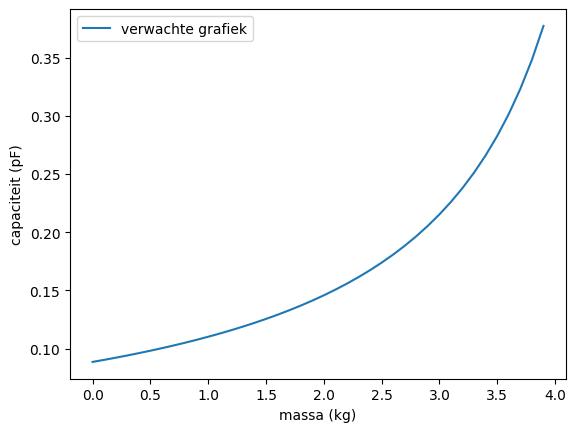

In [88]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
m=np.arange(0, 4, 0.1)
g=9.81
A=0.1*0.1
epsilonr = 1.00056
k = 50 #is een gok
d0=0.01
def verwachte_grafiek(m, epsilon0, epsilonr, A, d0, g, k):
    C= (epsilonr*epsilon0 * A / (d0-(m*g/k)))
    return C
plt.plot(m, verwachte_grafiek(m, epsilon0, epsilonr, A, 1, g, k)*1e12, label='verwachte grafiek')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 13.9 |45 |
| gemiddelde capaciteit| 20 |97.4 |
| maximale capaciteit| 30 |150 |

## Opdracht 6: Foto's werkende opstelling.


![foto sensor](eindopstelling.png)

## Opdracht 7: Plot de kalibratiegrafiek.

Text(0.5, 0, 'afstand (mm)')

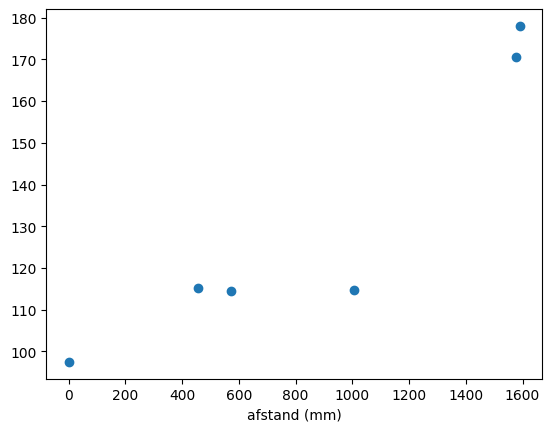

In [59]:
data1 = np.array([[0,97.5],[454,115.2],[573,114.4],[1006, 114.8],[568*2+454, 178],[568*2+440,170.5]])

plt.plot(data1[:,0], data1[:,1], 'o', label='gemeten data')
plt.xlabel('afstand (mm)')

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* de spons deuk niet linear in, het is eerst moeilijk en dan makkelijk dus het maakt een gekke sprong
* debovenste plaat blijft niet goed in balans

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.


![meting 1](werkendeSensor.jpeg)
![meting 2](werkendeSensor2.png)

[762.10268938   6.11854776]


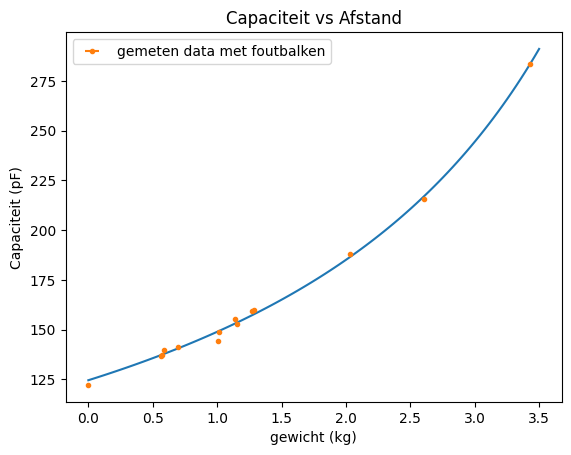

In [ ]:
from scipy.optimize import curve_fit

def f_fit(x, a, b):
    y = a/(b-x)
    return y

popt, pcov = curve_fit(f_fit, data[:,0], data[:,1], p0=(5e2, 4))
print(popt)
x_fit = np.linspace(0, 3.5, 100)
xerr = 0.001 #fout in de gewichten

data = np.array([[0,122.2], [0.7,141.1], [0.573,137.4], [0.584,139.8], [1.273, 159.2]
                 , [1.284,159.7], [1.157,152.8], [0.566,136.5], [1.006,144.3], [1.140,155.3], [1.013,148.7], [3.433, 283.7],[2.030, 188],[2.603,215.5]])

plt.plot(x_fit, f_fit(x_fit, *popt))
plt.xlabel('gewicht (kg)') 
plt.ylabel('Capaciteit (pF)')
plt.errorbar(data[:,0], data[:,1], xerr=xerr, fmt='o', label='gemeten data met foutbalken', markersize=3)
plt.title('Capaciteit vs Afstand')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De veren hadden mooi verband dat goed te voorspellen was. Aan de hand van de data blijkt dat het goed mogelijk is om met deze sensor een weegschaal te maken. De veren werkt veel beter dan de spons, omdat deze zich meer voorspelbaar gedragen. De verwachte grafiek was goed. De vlakke plaat formule zat in onze vewachting grafiek en deze klopte goed. De fout uit de gemeten gewichten was niet significant de grootste fout komt waarschijnlijk uit verschuiving van de platen t.o.v. elkaar

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.


![meting 1](werkendeSensor.jpeg)
![meting 2](werkendeSensor2.png)

[762.10268938   6.11854776]


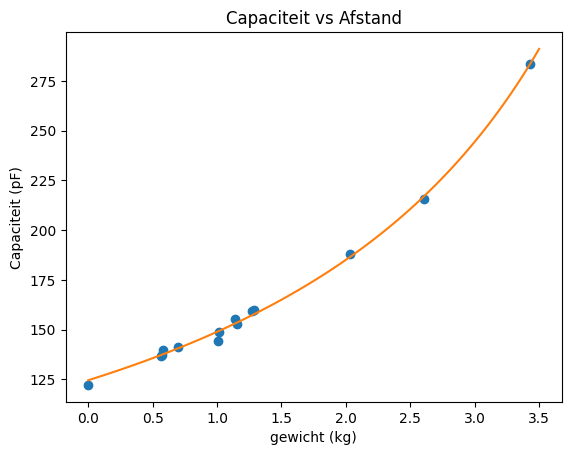

In [ ]:
from scipy.optimize import curve_fit

def f_fit(x, a, b):
    y = a/(b-x)
    return y

popt, pcov = curve_fit(f_fit, data[:,0], data[:,1], p0=(5e2, 4))
print(popt)
x_fit = np.linspace(0, 3.5, 100)

data = np.array([[0,122.2], [0.7,141.1], [0.573,137.4], [0.584,139.8], [1.273, 159.2]
                 , [1.284,159.7], [1.157,152.8], [0.566,136.5], [1.006,144.3], [1.140,155.3], [1.013,148.7], [3.433, 283.7],[2.030, 188],[2.603,215.5]])

plt.plot(data[:,0], data[:,1], 'o')
plt.plot(x_fit, f_fit(x_fit, *popt))
plt.xlabel('gewicht (kg)') 
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit vs Afstand')
plt.show()

[762.10268938   6.11854776]


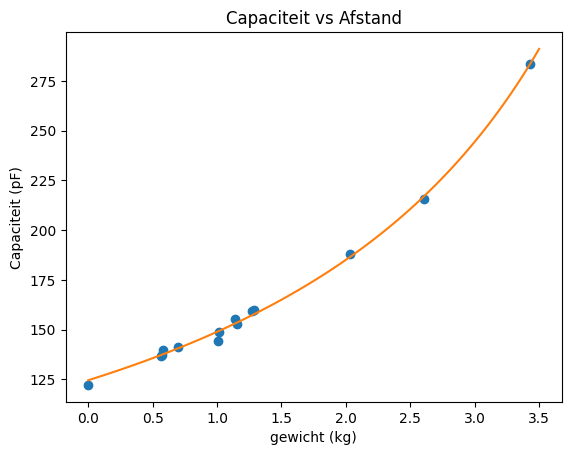

In [90]:
from scipy.optimize import curve_fit

def f_fit(x, a, b):
    y = a/(b-x)
    return y

popt, pcov = curve_fit(f_fit, data[:,0], data[:,1], p0=(5e2, 4))
print(popt)
x_fit = np.linspace(0, 3.5, 100)

data = np.array([[0,122.2], [0.7,141.1], [0.573,137.4], [0.584,139.8], [1.273, 159.2]
                 , [1.284,159.7], [1.157,152.8], [0.566,136.5], [1.006,144.3], [1.140,155.3], [1.013,148.7], [3.433, 283.7],[2.030, 188],[2.603,215.5]])



plt.plot(data[:,0], data[:,1], 'o')
plt.plot(x_fit, f_fit(x_fit, *popt))
plt.xlabel('gewicht (kg)') 
plt.ylabel('Capaciteit (pF)')
plt.title('Capaciteit vs Afstand')
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

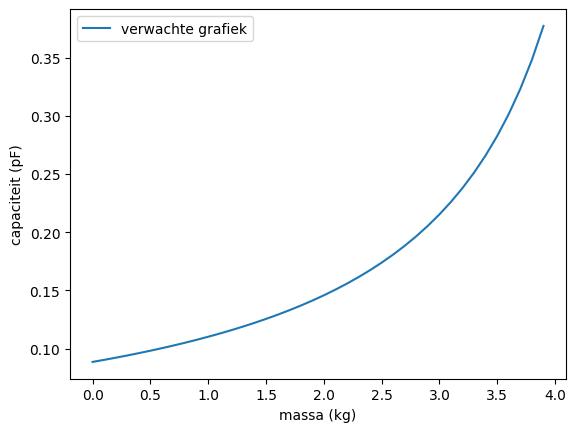

In [ ]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
m=np.arange(0, 4, 0.1)
g=9.81
A=0.1*0.1
epsilonr = 1.00056
k = 50 #is een gok
d0=0.01
def verwachte_grafiek(m, epsilon0, epsilonr, A, d0, g, k):
    C= (epsilonr*epsilon0 * A / (d0-(m*g/k)))
    return C
plt.plot(m, verwachte_grafiek(m, epsilon0, epsilonr, A, 1, g, k)*1e12, label='verwachte grafiek')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

[762.10268938   6.11854776]


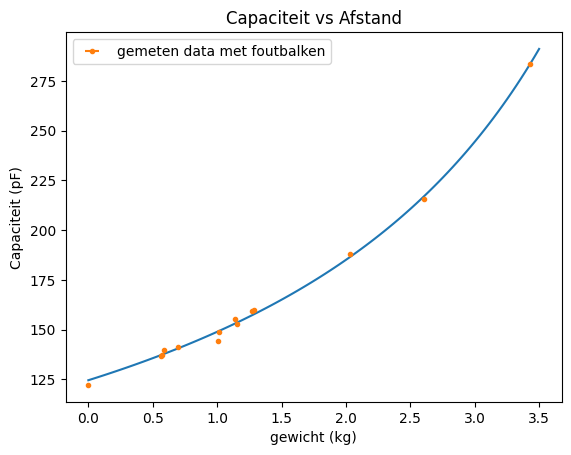

In [ ]:
from scipy.optimize import curve_fit

def f_fit(x, a, b):
    y = a/(b-x)
    return y

popt, pcov = curve_fit(f_fit, data[:,0], data[:,1], p0=(5e2, 4))
print(popt)
x_fit = np.linspace(0, 3.5, 100)
xerr = 0.001 #fout in de gewichten

data = np.array([[0,122.2], [0.7,141.1], [0.573,137.4], [0.584,139.8], [1.273, 159.2]
                 , [1.284,159.7], [1.157,152.8], [0.566,136.5], [1.006,144.3], [1.140,155.3], [1.013,148.7], [3.433, 283.7],[2.030, 188],[2.603,215.5]])

plt.plot(x_fit, f_fit(x_fit, *popt))
plt.xlabel('gewicht (kg)') 
plt.ylabel('Capaciteit (pF)')
plt.errorbar(data[:,0], data[:,1], xerr=xerr, fmt='o', label='gemeten data met foutbalken', markersize=3)
plt.title('Capaciteit vs Afstand')
plt.legend()
plt.show()

De veren hadden mooi verband dat goed te voorspellen was. aan de hand van de data blijkt dat het goed mogelijk is om met deze sensor een weegschaal te maken. De fout uit de gemeten gewichten was niet significant de grootste fout komt waarschijnlijk uit verschuiving van de platen t.o.v. elkaar